In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/adeenawaqar/bankloan-dataset/bankloans.csv


# Name : Adeena 

# Internship Machine Learning

# Task No 1 : Credit Scoring Model 

# Step 1: Import Libraries

In [2]:
import pandas as pd
import numpy as np

# for Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# for  Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# for Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

# Step 2: Load Dataset

In [3]:
df = pd.read_csv("/kaggle/input/datasets/adeenawaqar/bankloan-dataset/bankloans.csv")


# Step 3: Checking Dataset

In [4]:
df.head()

,age,ed,employ,address,income,debtinc,creddebt,othdebt,default
0,41,3,17,12,176,9.3,11.359392,5.008608,1.0
1,27,1,10,6,31,17.3,1.362202,4.000798,0.0
2,40,1,15,14,55,5.5,0.856075,2.168925,0.0
3,41,1,15,14,120,2.9,2.658720,0.821280,0.0
4,24,2,2,0,28,17.3,1.787436,3.056564,1.0


In [5]:
df.shape

(850, 9)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 850 entries, 0 to 849
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       850 non-null    int64  
 1   ed        850 non-null    int64  
 2   employ    850 non-null    int64  
 3   address   850 non-null    int64  
 4   income    850 non-null    int64  
 5   debtinc   850 non-null    float64
 6   creddebt  850 non-null    float64
 7   othdebt   850 non-null    float64
 8   default   700 non-null    float64
dtypes: float64(4), int64(5)
memory usage: 59.9 KB


In [7]:
df.describe()

,age,ed,employ,address,income,debtinc,creddebt,othdebt,default
count,850.000000,850.000000,850.000000,850.000000,850.000000,850.000000,850.000000,850.000000,700.000000
mean,35.029412,1.710588,8.565882,8.371765,46.675294,10.171647,1.576805,3.078789,0.261429
std,8.041432,0.927784,6.777884,6.895016,38.543054,6.719441,2.125840,3.398803,0.439727
min,20.000000,1.000000,0.000000,0.000000,13.000000,0.100000,0.011696,0.045584,0.000000
25%,29.000000,1.000000,3.000000,3.000000,24.000000,5.100000,0.382176,1.045942,0.000000
50%,34.000000,1.000000,7.000000,7.000000,35.000000,8.700000,0.885091,2.003243,0.000000
75%,41.000000,2.000000,13.000000,12.000000,55.750000,13.800000,1.898440,3.903001,1.000000
max,56.000000,5.000000,33.000000,34.000000,446.000000,41.300000,20.561310,35.197500,1.000000


# Step 4: Checking Missing Values.

In [8]:
df.isnull().sum()

age           0
ed            0
employ        0
address       0
income        0
debtinc       0
creddebt      0
othdebt       0
default     150
dtype: int64

# Step 5: Handle Missing Values

In [9]:
df = df.dropna(subset=["default"])

df.isnull().sum()

age         0
ed          0
employ      0
address     0
income      0
debtinc     0
creddebt    0
othdebt     0
default     0
dtype: int64

 # Stage 6: Check Target Distribution

In [10]:
df["default"] = df["default"].astype(int)

df["default"].value_counts()

default
0    517
1    183
Name: count, dtype: int64

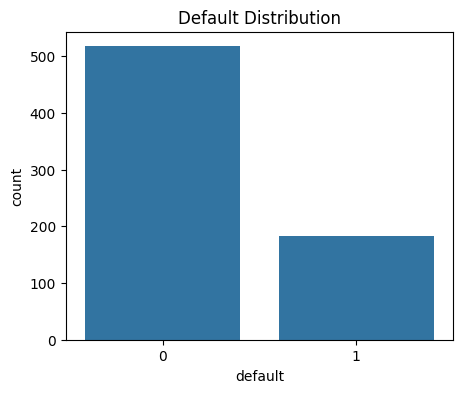

In [11]:
# target visualization

plt.figure(figsize=(5,4))
sns.countplot(x="default", data=df)
plt.title("Default Distribution")
plt.show()

In [12]:
# check datatype
df.dtypes

age           int64
ed            int64
employ        int64
address       int64
income        int64
debtinc     float64
creddebt    float64
othdebt     float64
default       int64
dtype: object

# Stage 7: Correlation

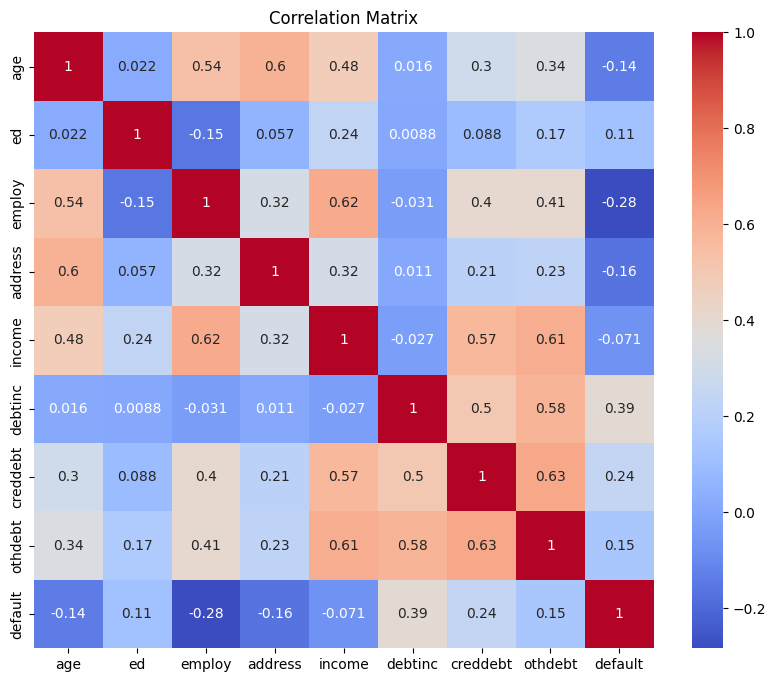

In [13]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

# Stage 8: Split Features and Target

In [14]:
X = df.drop("default", axis=1)

y = df["default"]

# Stage 9: Train Test Split

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Stage 10: Model Apply 

In [16]:
# 1) logistic Regression 

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)


print("Accuracy :", accuracy_score(y_test, pred_lr))
print("Precision :", precision_score(y_test, pred_lr))
print("Recall :", recall_score(y_test, pred_lr))
print("F1 Score :", f1_score(y_test, pred_lr))
print("ROC AUC :", roc_auc_score(y_test, pred_lr))

Accuracy : 0.85
Precision : 0.8148148148148148
Recall : 0.5789473684210527
F1 Score : 0.676923076923077
ROC AUC : 0.7649638802889577


In [17]:
# 2) decision Tree

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

pred_dt = dt.predict(X_test)


print("Accuracy :", accuracy_score(y_test, pred_dt))
print("Precision :", precision_score(y_test, pred_dt))
print("Recall :", recall_score(y_test, pred_dt))
print("F1 Score :", f1_score(y_test, pred_dt))
print("ROC AUC :", roc_auc_score(y_test, pred_dt))

Accuracy : 0.7571428571428571
Precision : 0.5476190476190477
Recall : 0.6052631578947368
F1 Score : 0.575
ROC AUC : 0.7094943240454076


In [18]:
# 3) Random Forest

rf = RandomForestClassifier(
    n_estimators= 100,
    random_state=42
)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

print("Accuracy :", accuracy_score(y_test, pred_rf))
print("Precision :", precision_score(y_test, pred_rf))
print("Recall :", recall_score(y_test, pred_rf))
print("F1 Score :", f1_score(y_test, pred_rf))
print("ROC AUC :", roc_auc_score(y_test, pred_rf))

Accuracy : 0.7785714285714286
Precision : 0.6521739130434783
Recall : 0.39473684210526316
F1 Score : 0.4918032786885246
ROC AUC : 0.6581527347781219


# Stage 11: Campare Models

In [19]:
results = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],

    "Accuracy":[
        accuracy_score(y_test,pred_lr),
        accuracy_score(y_test,pred_dt),
        accuracy_score(y_test,pred_rf)
    ],

    "Precision":[
        precision_score(y_test,pred_lr),
        precision_score(y_test,pred_dt),
        precision_score(y_test,pred_rf)
    ],

    "Recall":[
        recall_score(y_test,pred_lr),
        recall_score(y_test,pred_dt),
        recall_score(y_test,pred_rf)
    ],

    "F1 Score":[
        f1_score(y_test,pred_lr),
        f1_score(y_test,pred_dt),
        f1_score(y_test,pred_rf)
    ],

    "ROC AUC":[
        roc_auc_score(y_test,pred_lr),
        roc_auc_score(y_test,pred_dt),
        roc_auc_score(y_test,pred_rf)
    ]

})

results

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.850000,0.814815,0.578947,0.676923,0.764964
1,Decision Tree,0.757143,0.547619,0.605263,0.575000,0.709494
2,Random Forest,0.778571,0.652174,0.394737,0.491803,0.658153


# Stage 12: Confusion Matrix (Best Model)

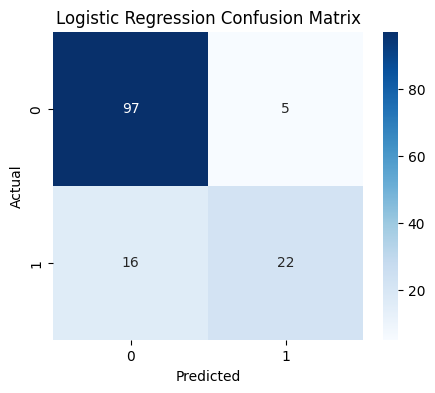

In [20]:
# Confusion Matrix

cm = confusion_matrix(y_test, pred_lr)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")

plt.show()

# Stage 13: Classification Report 

In [21]:
print(classification_report(y_test, pred_lr))

              precision    recall  f1-score   support

           0       0.86      0.95      0.90       102
           1       0.81      0.58      0.68        38

    accuracy                           0.85       140
   macro avg       0.84      0.76      0.79       140
weighted avg       0.85      0.85      0.84       140



# .pkl file for front end

In [22]:
import joblib

joblib.dump(lr, "credit_risk_model.pkl")

['credit_risk_model.pkl']